In [1]:
import _referAsMain
import sys; print(sys.version_info)
from datasets import load_dataset
import torch, random, time, math
from IPython.display import SVG, display

added '/home/time/Bureau/pfe/PFE_LLM_art_generation' to import paths
sys.version_info(major=3, minor=10, micro=19, releaselevel='final', serial=0)


/home/time/Bureau/pfe/PFE_LLM_art_generation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

Torch version: 2.9.1+cu128
CUDA available: True
CUDA version: 12.8
Device count: 1


In [3]:
# Load Alpaca format
dataset = load_dataset("xingxm/SVGX-SFT-1M", split="train", data_files="SVGX_SFT_GEN_51k.json")

In [4]:
print(len(dataset))

514172


In [5]:
print(f"{dataset.size_in_bytes:_d}")

2_346_931_760


In [6]:
print(dataset[0])

{'instruction': 'Generate an SVG illustration from the given description.', 'input': 'SVG illustration of person in suit levitating.', 'output': '<svg enable-background="new 0 0 128 128" viewBox="0 0 128 128" xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink"><radialGradient id="a" cx="63.9995" cy="8.0164" gradientTransform="matrix(1 0 0 -.305 0 122.4395)" gradientUnits="userSpaceOnUse" r="15.2017"><stop offset=".1396" stop-color="#504f4f" stop-opacity=".8"/><stop offset=".8722" stop-color="#616161" stop-opacity="0"/></radialGradient><radialGradient id="b" cx="108.9787" cy="96.3683" gradientTransform="matrix(1 0 0 .5046 -39.7364 -17.1289)" gradientUnits="userSpaceOnUse" r="8.3693"><stop offset=".7275" stop-color="#6d4c41" stop-opacity="0"/><stop offset="1" stop-color="#6d4c41"/></radialGradient><radialGradient id="c" cx="100.7358" cy="97.6126" gradientTransform="matrix(-.9057 .4354 -.3144 -.6903 199.4155 53.7455)" gradientUnits="userSpaceOnUse" r="2.4733"><st

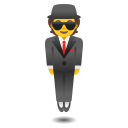

In [7]:
display(SVG(data=dataset[0]["output"]))

In [8]:
import LLM.nanochat.gpt as nanoChatModel
import LLM.nanochat.tokenizer as tokenizerLib
from LLM.nanochat.common import compute_init, autodetect_device_type

In [9]:
device_type = "cuda"
device_type = (autodetect_device_type() if device_type == "" else device_type)
ddp, ddp_rank, ddp_local_rank, ddp_world_size, device = compute_init(device_type)

2026-02-23 15:24:36,764 - LLM.nanochat.common - INFO - Distributed world size: 1


In [10]:
tokenizerPreTrained = tokenizerLib.HuggingFaceTokenizer.from_pretrained("gpt2")
#tokenizerPreTrained = tokenizerLib.HuggingFaceTokenizer.from_pretrained("xlnet/xlnet-base-cased")

2026-02-23 15:24:36,893 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/tokenizer.json "HTTP/1.1 200 OK"


In [11]:
from tokenizer_pfe.tokenizer_project import SPECIAL_TOKENS

In [12]:
tokenizerTrainedSmallest = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    dataset[: 100]["output"], vocab_size=2048, special_tokens= SPECIAL_TOKENS)

In [13]:
tokenizerTrainedSmall = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    dataset[: 5_000]["output"], vocab_size=2048, special_tokens= SPECIAL_TOKENS)

In [14]:
tokenizerTrainedMedium = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    dataset[: 25_000]["output"], vocab_size=2048, special_tokens= SPECIAL_TOKENS)

In [15]:
tokenizerTrained = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    dataset[: 100_000]["output"], vocab_size=2048, special_tokens= SPECIAL_TOKENS)

In [16]:
tokenizerTrainedLarge = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    dataset[: 3_000_000]["output"], vocab_size=2048*2, special_tokens= SPECIAL_TOKENS)

In [17]:
tokenizerTrainedLargest = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    dataset[: 15_000_000]["output"], vocab_size=2048*2, special_tokens= SPECIAL_TOKENS)

In [18]:
tokenizer = tokenizerTrainedMedium
vocab_size = tokenizer.get_vocab_size()
print(vocab_size)
display(sorted([(id, tk) for tk, id in tokenizer.tokenizer.get_vocab().items()], reverse=False))
OutStart_Token = "<|output_start|>"
OutEnd_Token = "<|output_end|>"
OutEnd_ids = tokenizer.encode(OutEnd_Token); assert len(OutEnd_ids) == 1
OutEnd_id = OutEnd_ids[0]; del OutEnd_ids

1698


[(0, '<|output_start|>'),
 (1, '<|output_end|>'),
 (2, '!'),
 (3, '"'),
 (4, '#'),
 (5, '$'),
 (6, '%'),
 (7, '&'),
 (8, "'"),
 (9, '('),
 (10, ')'),
 (11, '*'),
 (12, '+'),
 (13, ','),
 (14, '-'),
 (15, '.'),
 (16, '/'),
 (17, '0'),
 (18, '1'),
 (19, '2'),
 (20, '3'),
 (21, '4'),
 (22, '5'),
 (23, '6'),
 (24, '7'),
 (25, '8'),
 (26, '9'),
 (27, ':'),
 (28, ';'),
 (29, '<'),
 (30, '='),
 (31, '>'),
 (32, '?'),
 (33, '@'),
 (34, 'A'),
 (35, 'B'),
 (36, 'C'),
 (37, 'D'),
 (38, 'E'),
 (39, 'F'),
 (40, 'G'),
 (41, 'H'),
 (42, 'I'),
 (43, 'J'),
 (44, 'K'),
 (45, 'L'),
 (46, 'M'),
 (47, 'N'),
 (48, 'O'),
 (49, 'P'),
 (50, 'Q'),
 (51, 'R'),
 (52, 'S'),
 (53, 'T'),
 (54, 'U'),
 (55, 'V'),
 (56, 'W'),
 (57, 'X'),
 (58, 'Y'),
 (59, 'Z'),
 (60, '['),
 (61, '\\'),
 (62, ']'),
 (63, '^'),
 (64, '_'),
 (65, '`'),
 (66, 'a'),
 (67, 'b'),
 (68, 'c'),
 (69, 'd'),
 (70, 'e'),
 (71, 'f'),
 (72, 'g'),
 (73, 'h'),
 (74, 'i'),
 (75, 'j'),
 (76, 'k'),
 (77, 'l'),
 (78, 'm'),
 (79, 'n'),
 (80, 'o'),
 (81, 'p'

In [19]:
print(type(tokenizer.tokenizer))

<class 'tokenizers.Tokenizer'>


In [20]:
aspect_ratio = 10.5
head_dim = 128
max_seq_len = 2048*8
window_pattern = "SSSL"

def build_model_meta(depth):
    """Build a model on meta device for a given depth (shapes/dtypes only, no data)."""
    # Model dim is nudged up to nearest multiple of head_dim for clean division
    # (FA3 requires head_dim divisible by 8, and this guarantees head_dim == args.head_dim exactly)
    base_dim = depth * aspect_ratio
    model_dim = int(((base_dim + head_dim - 1) // head_dim) * head_dim)
    num_heads = int(model_dim // head_dim)
    config = nanoChatModel.GPTConfig(
        sequence_len=max_seq_len, vocab_size=vocab_size,
        n_layer=depth, n_head=num_heads, n_kv_head=num_heads, n_embd=model_dim,
        window_pattern=window_pattern,
    )
    print(config)
    with torch.device("meta"):
        model_meta = nanoChatModel.GPT(config)
    return model_meta

model = build_model_meta(6)
model.to_empty(device=device) # 2) All tensors get storage on target device but with uninitialized (garbage) data
model.init_weights() # 3) All tensors get initialized
optimizer = model.setup_optimizer()

params = model.num_scaling_params(); print(params.items())
params_Embed = (params['wte'] + params['value_embeds'])
print(f"{params['total']:_d} params "
      f"(with embeding: {params_Embed:_d} | "
      f"last layer: {params['lm_head']:_d} | "
      f"transformer: {params['transformer_matrices']:_d})"
    )
model = model.bfloat16()

model = torch.compile(model, dynamic=False) # the inputs to model will never change shape so dynamic=False is safe
#model.eval();


GPTConfig(sequence_len=16384, vocab_size=1698, n_layer=6, n_head=1, n_kv_head=1, n_embd=128, window_pattern='SSSL')
Padding vocab_size from 1698 to 1728 for efficiency
Scaling the LR for the AdamW parameters ∝1/√(128/768) = 2.449490
dict_items([('wte', 221184), ('value_embeds', 663552), ('lm_head', 221184), ('transformer_matrices', 1179744), ('scalars', 12), ('total', 2285676)])
2_285_676 params (with embeding: 884_736 | last layer: 221_184 | transformer: 1_179_744)


In [21]:
svg = dataset[-57]["output"]
encoded = tokenizer.tokenizer.encode(svg)
print(f"{len(svg):_d}, {len(encoded.ids):_d}")
print(encoded.ids)
print(" ".join(encoded.tokens))

16_623, 11_669
[477, 494, 259, 269, 25, 3, 483, 259, 17, 222, 17, 222, 269, 25, 222, 269, 25, 3, 492, 259, 269, 25, 3, 465, 259, 467, 461, 466, 458, 20, 468, 16, 289, 261, 476, 399, 274, 275, 259, 78, 222, 335, 15, 327, 222, 321, 15, 300, 260, 258, 17, 15, 290, 222, 17, 258, 17, 15, 312, 258, 17, 15, 277, 258, 17, 15, 321, 258, 17, 15, 291, 258, 17, 15, 366, 258, 17, 15, 305, 258, 19, 15, 269, 222, 17, 15, 374, 258, 18, 15, 397, 222, 17, 15, 291, 222, 17, 15, 299, 258, 17, 15, 369, 222, 22, 15, 397, 258, 285, 15, 313, 222, 309, 15, 366, 258, 298, 15, 325, 557, 222, 18, 15, 321, 222, 18, 15, 321, 222, 17, 222, 18, 15, 261, 222, 18, 15, 261, 222, 17, 15, 382, 222, 19, 15, 355, 260, 258, 285, 15, 329, 222, 21, 15, 343, 258, 289, 15, 355, 222, 288, 15, 320, 258, 289, 15, 374, 222, 288, 15, 350, 557, 222, 18, 15, 321, 222, 18, 15, 321, 222, 17, 222, 17, 222, 18, 15, 261, 258, 18, 15, 332, 222, 18, 15, 261, 3, 281, 272, 951, 375, 265, 274, 275, 259, 78, 222, 382, 15, 357, 222, 304, 15, 385, 

In [22]:
def show(gen):
    results = []
    memStart = torch.cuda.memory.memory_reserved()
    for nb, token in enumerate(gen):
        decoded = tokenizer.decode([token])
        results.append(decoded)
        #print(decoded, end="", flush=True)
        print(nb, end="\r", flush=True)
        if token == OutEnd_id:
            break
        memCurr = torch.cuda.memory.memory_reserved()
        if (memCurr-memStart) > 2 * 1e9: # using ..Go
            torch.cuda.memory.empty_cache()
            
    torch.cuda.memory.empty_cache()
    print()
    return results

In [23]:
torch.cuda.memory.empty_cache()
inputs_text = (dataset[0]["input"] * 1) + OutStart_Token
#inputs_text =  "SVG of a brick." + OutStart_Token
tokens = tokenizer.encode(inputs_text)
print(f"nb tokens in the input: {len(tokens):_d}")

print(inputs_text)
nbToGen = 100
tStart = time.perf_counter()
with torch.device(device):
    generated = show(model.generate(
        tokens=tokens, max_tokens=nbToGen, 
        temperature=1, top_k=None, seed=random.randint(0, 10_000)))
tTaken = (time.perf_counter() - tStart)
print(f'took: {tTaken:.2f} sec, ({len(generated)/tTaken:.2f} token/sec)')
print(inputs_text + "".join(generated))

nb tokens in the input: 30
SVG illustration of person in suit levitating.<|output_start|>
99
took: 0.53 sec, (188.38 token/sec)
SVG illustration of person in suit levitating.<|output_start|>fffafe11bfffefabgroundeaab></FFDB�线:#	Crcmatrixted result k   feeccbambcbc:urlfccnonzbdccd减dbbedbdcacddescffaa�并)"/></fdfemaskaadcdde�形�xlinkabadbc zdfc52�DDeeecFCdfbebddcb24� fillite values92ece SaceefeeacccBcacdDevffcddcdcacd st�deadIaskbafff-widthdedfe-filters59daeacbeefdffbaCCDbedffeda35&dededebaafFFDesmp&cacdopacityeafaliEdbcfffe stylebbdefb


In [24]:
torch.cuda.memory.empty_cache()
start = 0
nbToGen = 100
tStart = time.perf_counter()
model.train()
lossEmaCoeff = 1/50

nb = 0
try:
    emaLoss = float("nan")
    samples = dataset[start: start+nbToGen]
    for nb, (input_text, output_text) in enumerate(zip(samples["input"], samples["output"])):
        tokens = tokenizer.encode(input_text + OutStart_Token + output_text + OutEnd_Token*2)
        tokens = tokens[: model.config.sequence_len//2]
        ids = torch.tensor([tokens], dtype=torch.long, device=device) # add batch dim
        with torch.device(device):
            loss = model.forward(ids[:, : -1], ids[:, 1: ])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss = loss.detach().item()
        if math.isnan(emaLoss):
            emaLoss = loss
        else: emaLoss = (emaLoss * (1-lossEmaCoeff) + (loss * lossEmaCoeff))
        torch.cuda.memory.empty_cache()
        print(f"trained on input n°{start+nb}: {len(tokens):_d} tokens, loss: {loss:.4g}, emaLoss: {emaLoss:.4g}")
finally:
    tTaken = (time.perf_counter() - tStart)
    print(f'took: {tTaken:.2f} sec, ({(nb+1)/tTaken:.2f} samples/sec)')
    print(f"new start at: {start + nb}")

trained on input n°0: 6_964 tokens, loss: 7.437, emaLoss: 7.437
trained on input n°1: 7_030 tokens, loss: 8.089, emaLoss: 7.45
trained on input n°2: 1_184 tokens, loss: 7.223, emaLoss: 7.445
trained on input n°3: 1_266 tokens, loss: 5.967, emaLoss: 7.416
trained on input n°4: 2_655 tokens, loss: 4.969, emaLoss: 7.367
trained on input n°5: 2_707 tokens, loss: 5.269, emaLoss: 7.325
trained on input n°6: 4_460 tokens, loss: 3.632, emaLoss: 7.251


W0223 15:27:23.301000 30533 torch/_dynamo/convert_frame.py:1358] [0/8] torch._dynamo hit config.recompile_limit (8)
W0223 15:27:23.301000 30533 torch/_dynamo/convert_frame.py:1358] [0/8]    function: 'forward' (/home/time/Bureau/pfe/PFE_LLM_art_generation/LLM/nanochat/gpt.py:388)
W0223 15:27:23.301000 30533 torch/_dynamo/convert_frame.py:1358] [0/8]    last reason: 0/7: tensor 'idx' size mismatch at index 1. expected 4540, actual 2224
W0223 15:27:23.301000 30533 torch/_dynamo/convert_frame.py:1358] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0223 15:27:23.301000 30533 torch/_dynamo/convert_frame.py:1358] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html


trained on input n°7: 4_541 tokens, loss: 3.279, emaLoss: 7.172
trained on input n°8: 2_225 tokens, loss: 3.085, emaLoss: 7.09
trained on input n°9: 2_267 tokens, loss: 2.915, emaLoss: 7.006
trained on input n°10: 3_160 tokens, loss: 2.416, emaLoss: 6.915
trained on input n°11: 3_203 tokens, loss: 2.338, emaLoss: 6.823
trained on input n°12: 2_601 tokens, loss: 2.247, emaLoss: 6.731
trained on input n°13: 2_652 tokens, loss: 2.232, emaLoss: 6.642
trained on input n°14: 1_475 tokens, loss: 3.122, emaLoss: 6.571
trained on input n°15: 1_515 tokens, loss: 2.96, emaLoss: 6.499
trained on input n°16: 699 tokens, loss: 2.539, emaLoss: 6.42
trained on input n°17: 740 tokens, loss: 2.455, emaLoss: 6.34
trained on input n°18: 2_552 tokens, loss: 2.677, emaLoss: 6.267
trained on input n°19: 2_601 tokens, loss: 2.648, emaLoss: 6.195
trained on input n°20: 1_611 tokens, loss: 2.756, emaLoss: 6.126
trained on input n°21: 1_666 tokens, loss: 2.685, emaLoss: 6.057
trained on input n°22: 1_964 tokens,

In [25]:
# a b c d e <start> f g h <end>
# b c d e <start> f g h <end> <end>

In [26]:
nb = 1000
totalTokens = sum(len(tokenizerTrainedMedium.encode(line)) for line in dataset[-nb: ]["output"])
nbChars = sum(len(line) for line in dataset[-nb: ]["output"])
print(f"estimated outputChars/tokens: {nbChars/totalTokens:.2f}")
print(f"estimated tokens/output: {totalTokens/nb:.2f}")
print(f"estimated chars/output: {nbChars/nb:.2f}")

estimated outputChars/tokens: 1.46
estimated tokens/output: 3794.28
estimated chars/output: 5546.09
